# Crystallographic Fourier Patterns and Quasicrystals

A **Fourier crystal** is an image whose intensity is the squared modulus of a sum of plane waves:
$$
I(x,y) = \left|\sum_{k=1}^{K} e^{2\pi i \rho (x \cos\theta_k + y \sin\theta_k)}\right|^2,
$$
where the $K$ wave directions $\theta_k = 2\pi k / K$ are equally spaced on the circle and $\rho$ is the spatial frequency. The resulting pattern has the same $K$-fold rotational symmetry as the generating wave directions.

## Classical crystallography

For $K \in \{2, 3, 4, 6\}$, the pattern is compatible with a **Bravais lattice** and tiles the plane periodically — the only symmetry orders allowed by the crystallographic restriction theorem. The Fourier series converges to a periodic function whose Fourier support lies on finitely many frequencies.

## Quasicrystals

For $K = 5, 7, 8, 10, 12$, the symmetry is **incompatible with periodicity**: the 5-fold or 7-fold rotationally symmetric patterns cannot tile the plane with a lattice. The resulting images are **quasiperiodic** — almost periodic but lacking translational symmetry. They are the continuous analogues of **Penrose tilings** and **quasicrystals** discovered experimentally by Shechtman (Nobel Prize 2011).

## Poisson disk sampling

A **Poisson disk process** is a random point set where no two points are closer than a minimum distance $r$. The Fourier transform of such a point set exhibits a **quasi-crystalline annular ring** — high power at frequency $\approx 1/r$ with approximate rotational symmetry, mimicking the diffraction pattern of amorphous solids.

## Interference and moiré

Adding more wave directions increases the number of interference terms, producing finer and more complex **moiré patterns**. The peak intensity scales as $K^2$ (coherent summation), while the envelope localizes at points of constructive interference.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

plt.rcParams['figure.dpi'] = 120

## Generating Fourier crystal patterns

We place $K$ unit waves with uniformly spaced directions and sum their complex amplitudes. The intensity $|\sum_k e^{2\pi i \rho \langle z_k, x\rangle}|^2$ is real and nonneg­ative.

In [2]:
n = 512
t = np.linspace(-1, 1, n)
Y, X = np.meshgrid(t, t)

def fourier_crystal(K, rho=8.0):
    """Sum of K plane waves with K-fold rotational symmetry."""
    angles = 2 * np.pi * np.arange(K) / K
    M = np.zeros((n, n), dtype=complex)
    for theta in angles:
        M += np.exp(2j * np.pi * rho * (X * np.cos(theta) + Y * np.sin(theta)))
    return np.abs(M)**2

print('Fourier crystal generator ready.')

Fourier crystal generator ready.


## Gallery: from periodic to quasicrystalline symmetry

We display patterns for $K = 2, 3, 4, 5, 6, 7, 8, 12$. Even values of $K$ tend to produce checkerboard-like patterns; odd values produce star-like quasicrystalline motifs.

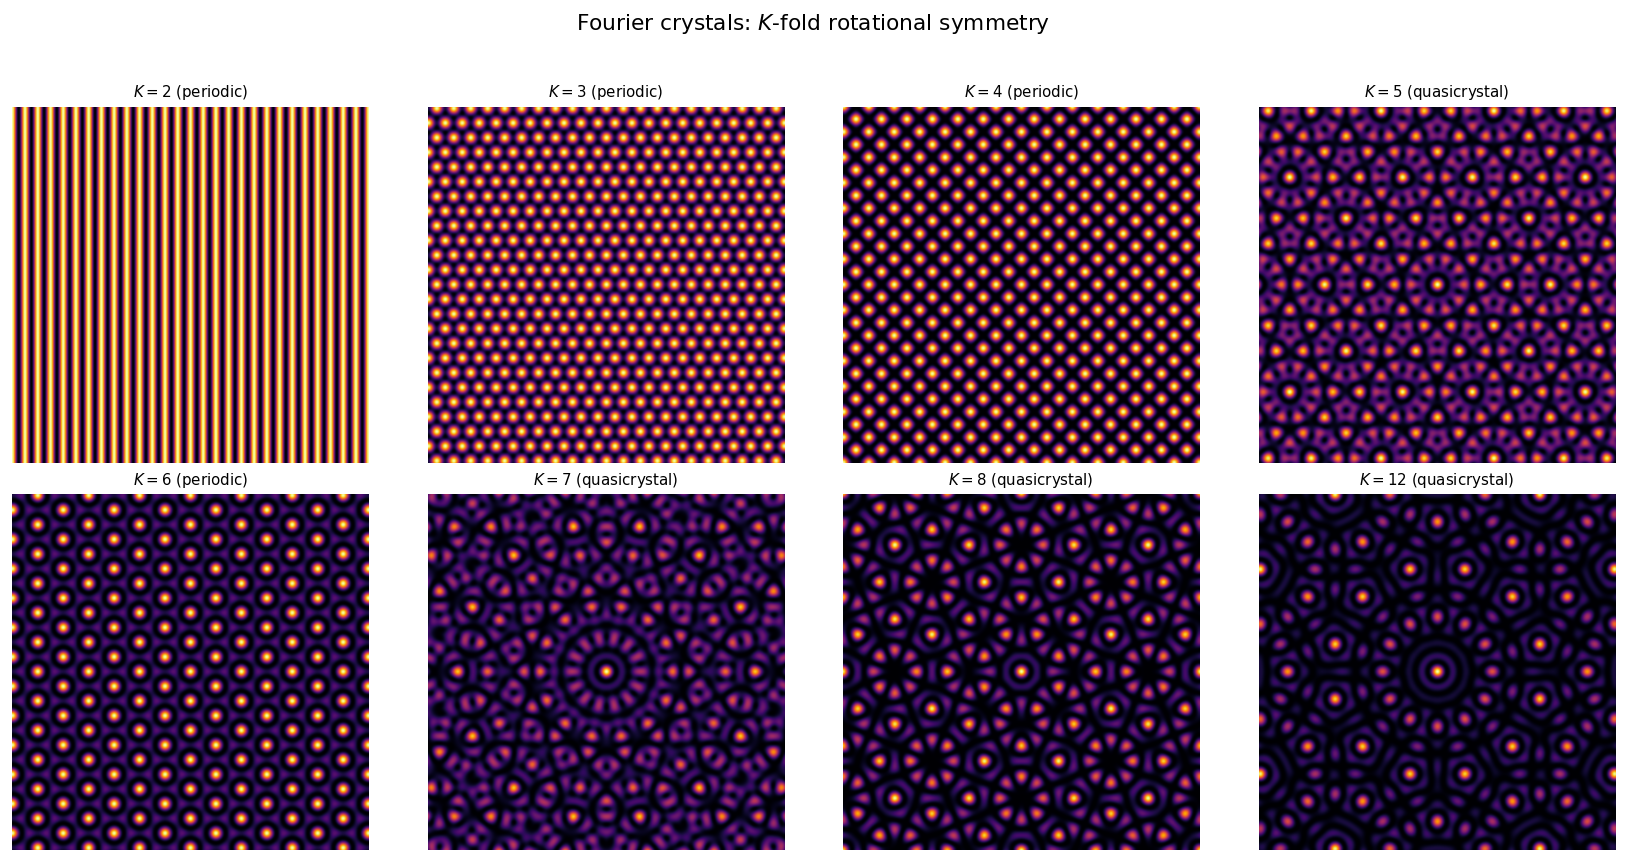

In [3]:
K_values = [2, 3, 4, 5, 6, 7, 8, 12]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, K in zip(axes.ravel(), K_values):
    I = fourier_crystal(K, rho=7)
    ax.imshow(I.T, extent=[-1,1,-1,1], origin='lower',
              cmap='inferno', interpolation='bilinear')
    periodic = K in [2, 3, 4, 6]
    label = f'$K={K}$' + (' (periodic)' if periodic else ' (quasicrystal)')
    ax.set_title(label, fontsize=9)
    ax.axis('off')

fig.suptitle('Fourier crystals: $K$-fold rotational symmetry', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Effect of frequency $\rho$ on pattern scale

The parameter $\rho$ controls the spatial frequency: larger $\rho$ produces finer interference fringes. We fix $K = 5$ (Penrose-type quasicrystal) and vary $\rho$.

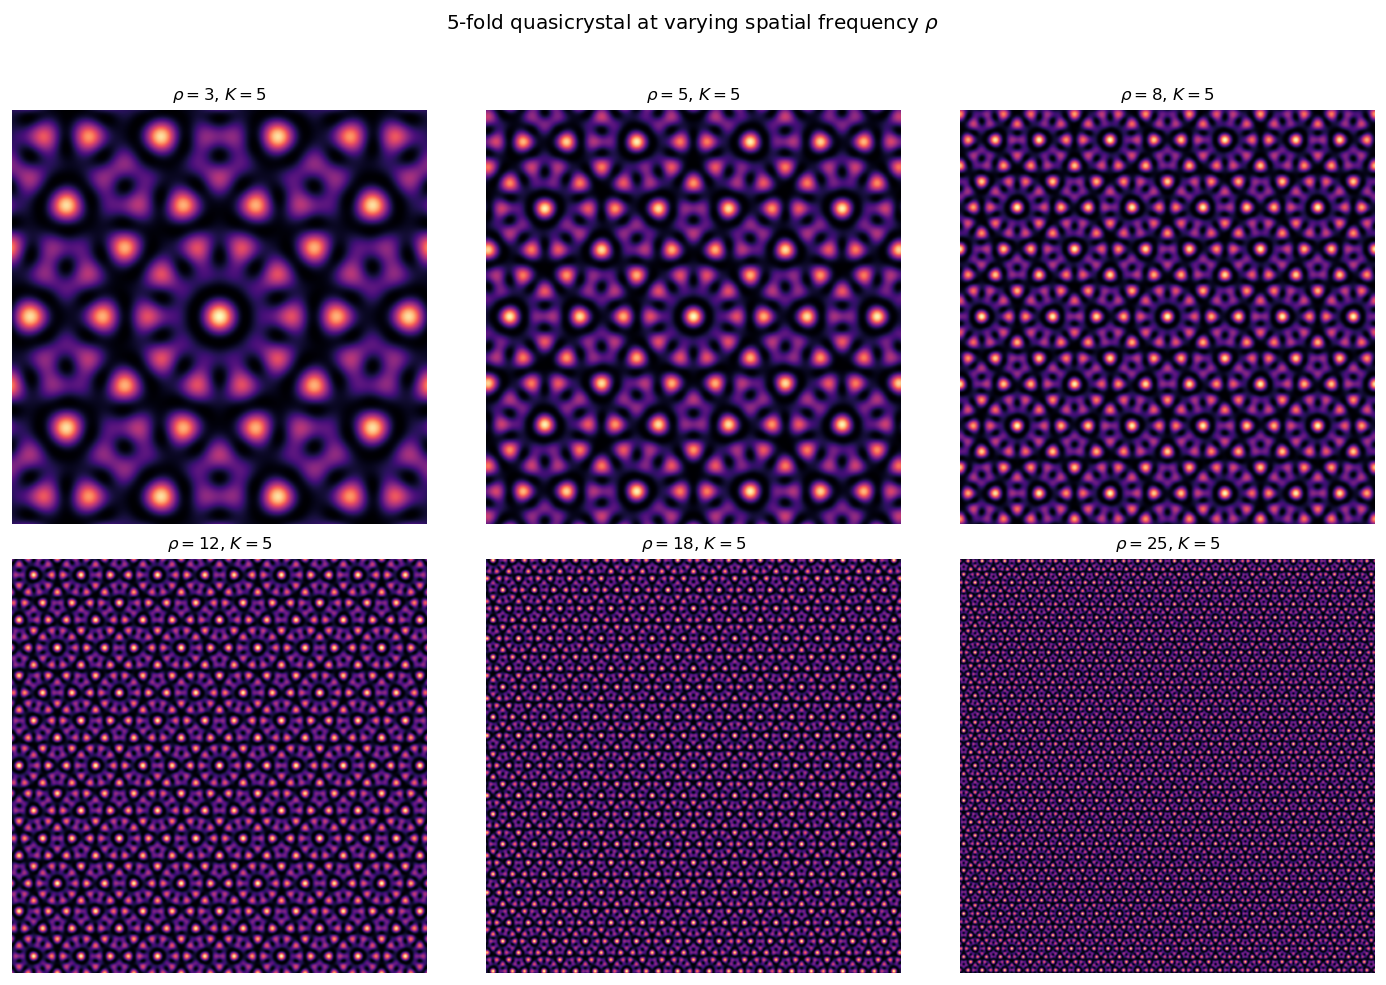

In [4]:
rho_values = [3, 5, 8, 12, 18, 25]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, rho in zip(axes.ravel(), rho_values):
    I = fourier_crystal(5, rho=rho)
    ax.imshow(I.T, extent=[-1,1,-1,1], origin='lower',
              cmap='magma', interpolation='bilinear')
    ax.set_title(fr'$\rho = {rho}$, $K=5$', fontsize=10)
    ax.axis('off')

fig.suptitle(r'5-fold quasicrystal at varying spatial frequency $\rho$', y=1.02)
plt.tight_layout()
plt.show()

## Poisson disk sampling and its Fourier spectrum

A Poisson disk point set is generated by Bridson's dart-throwing algorithm: accept new points only if they are further than $r_{\min}$ from all existing points. The result is a **blue-noise** distribution — uniform without clustering. Its power spectrum displays a characteristic annular ring at $|\xi| \approx 1/r_{\min}$.

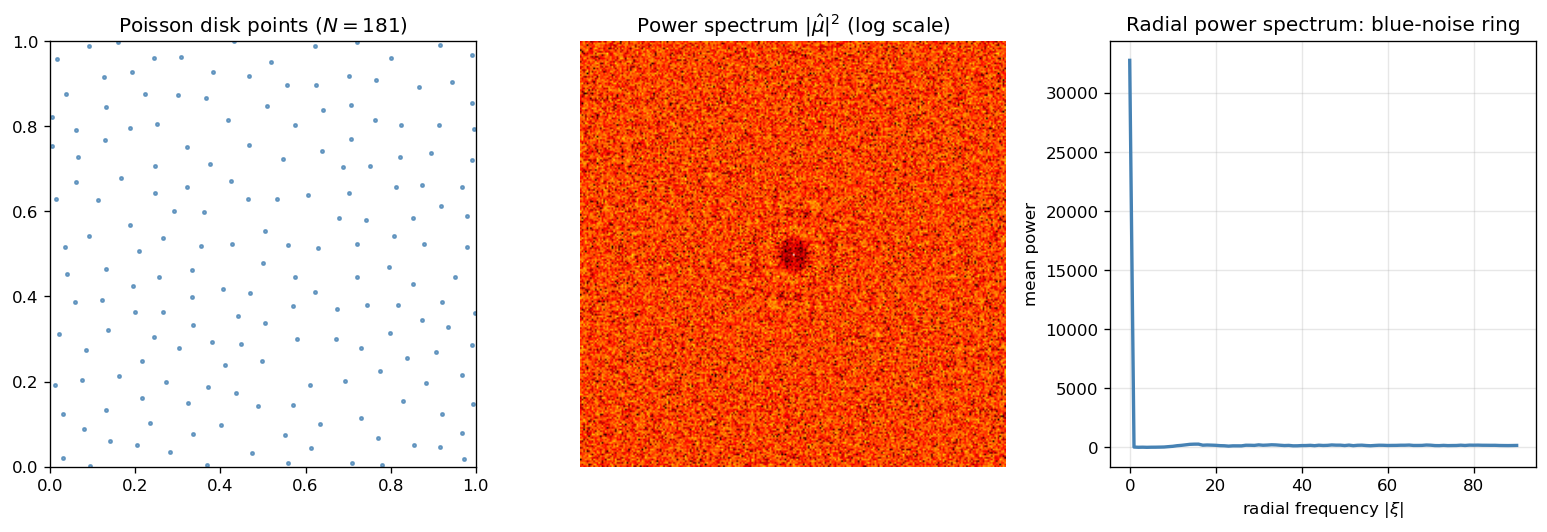

In [5]:
def poisson_disk_2d(width=1.0, r_min=0.05, seed=42):
    """Simple Poisson disk sampling via dart throwing."""
    rng = np.random.default_rng(seed)
    points = []
    max_attempts = 30 * int((width / r_min)**2)
    for _ in range(max_attempts):
        p = rng.uniform(0, width, 2)
        if all(np.linalg.norm(p - q) >= r_min for q in points):
            points.append(p)
    return np.array(points)

def points_to_image(pts, n=256):
    """Rasterize point set to a binary image."""
    img = np.zeros((n, n))
    idx = np.clip((pts * n).astype(int), 0, n-1)
    img[idx[:,0], idx[:,1]] = 1.0
    return img

pts = poisson_disk_2d(r_min=0.06, seed=7)
img_pts = points_to_image(pts, n=256)

# Power spectrum
F = np.fft.fftshift(np.abs(np.fft.fft2(img_pts))**2)
F_log = np.log1p(F)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].scatter(pts[:,0], pts[:,1], s=4, c='steelblue', alpha=0.7)
axes[0].set_aspect('equal'); axes[0].set_title(f'Poisson disk points ($N={len(pts)}$)')
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1)

axes[1].imshow(F_log, cmap='hot', interpolation='bilinear')
axes[1].set_title('Power spectrum $|\\hat{\\mu}|^2$ (log scale)')
axes[1].axis('off')

# Radial profile of the spectrum
cx, cy = 128, 128
u, v = np.mgrid[-128:128, -128:128]
r = np.sqrt(u**2 + v**2).ravel().astype(int)
r_max = 90
radial = np.array([F.ravel()[r==ri].mean() for ri in range(r_max+1)])
axes[2].plot(radial, lw=2, color='steelblue')
axes[2].set_xlabel('radial frequency $|\\xi|$')
axes[2].set_ylabel('mean power')
axes[2].set_title('Radial power spectrum: blue-noise ring')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Comparing Fourier atom patterns side by side

We place the $K$-fold patterns alongside for $K = 5$ (Penrose quasicrystal) and $K=6$ (hexagonal crystal), highlighting the subtle difference between crystalline and quasicrystalline order.

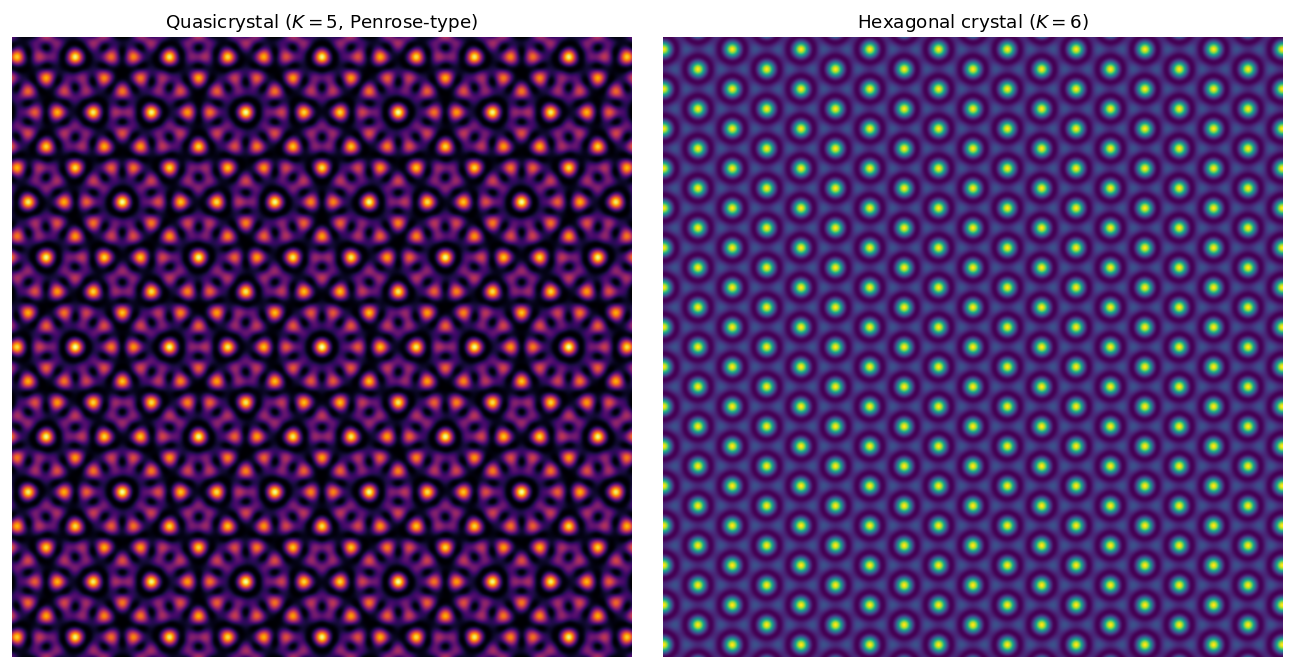

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
cmaps = ['inferno', 'viridis']
params = [(5, 'Quasicrystal ($K=5$, Penrose-type)'), (6, 'Hexagonal crystal ($K=6$)')]

for ax, (K, title), cmap in zip(axes, params, cmaps):
    I = fourier_crystal(K, rho=9)
    ax.imshow(I.T, extent=[-1,1,-1,1], origin='lower',
              cmap=cmap, interpolation='bilinear')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Interactive: sweep $K$ and $\rho$

Drag the sliders to explore how the symmetry order and frequency shape the interference pattern.

In [7]:
def show_crystal(K=5, rho=8.0):
    I = fourier_crystal(K, rho)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(I.T, extent=[-1,1,-1,1], origin='lower',
              cmap='inferno', interpolation='bilinear')
    periodic = K in [2, 3, 4, 6]
    kind = 'periodic crystal' if periodic else 'quasicrystal'
    ax.set_title(fr'$K={K}$, $\rho={rho:.1f}$ — {kind}', fontsize=11)
    ax.axis('off')
    plt.tight_layout(); plt.show()

interact(show_crystal,
         K=IntSlider(value=5, min=2, max=15, step=1, description='$K$'),
         rho=FloatSlider(value=8.0, min=2.0, max=20.0, step=0.5,
                         description=r'$\rho$'));

interactive(children=(IntSlider(value=5, description='$K$', max=15, min=2), FloatSlider(value=8.0, description…

## Bibliographical resources

- Shechtman, D., Blech, I., Gratias, D. and Cahn, J. W. (1984). Metallic phase with long-range orientational order and no translational symmetry. *Physical Review Letters*, 53(20), 1951–1953.
- de Bruijn, N. G. (1981). Algebraic theory of Penrose's non-periodic tilings of the plane. *Indagationes Mathematicae*, 84(1), 39–66.
- Penrose, R. (1974). The role of aesthetics in pure and applied mathematical research. *Bulletin of the Institute of Mathematics and its Applications*, 10, 266–271.
- Bridson, R. (2007). Fast Poisson disk sampling in arbitrary dimensions. *ACM SIGGRAPH 2007 Sketches*, Article 22.
- Lagae, A. and Dutré, P. (2008). A comparison of methods for generating Poisson disk distributions. *Computer Graphics Forum*, 27(1), 114–129.